<a href="https://colab.research.google.com/github/clementeyquem/Linear_Regression/blob/main/Linear_Regression_Module_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

mesure de spread, de yield, le yield to worst / maturity ; modified duration ; les ratings..
Analyse Financière/Crédit, Lecture des comptes, les états financiers, ce qu'est le HY, la particularité vs IG
niveaux des indices / taux directeurs ...

In [72]:
# =============================================================================
# MODULE 3 — Cross-Validation Temporelle : TimeSeriesSplit (Walk-Forward)
# =============================================================================

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

In [74]:
# =============================================================================
# 1. DONNÉES
# =============================================================================

import yfinance as yf
spx = yf.download("^GSPC", start="2013-01-01", end="2019-12-31", auto_adjust=True)
vix = yf.download("^VIX", start="2013-01-01", end="2019-12-31", auto_adjust=True)
spx_close = spx['Close'].squeeze()
vix_close = vix['Close'].squeeze()
log_ret = np.log(spx_close / spx_close.shift(1))
realized_vol = log_ret.rolling(21).std() * np.sqrt(252) * 100
df = pd.DataFrame({'VIX': vix_close, 'RealizedVol': realized_vol}).dropna()



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [75]:
# =============================================================================
# 2. FEATURE ENGINEERING
# =============================================================================

df['VIX_lag1'] = df['VIX'].shift(1)
df['VIX_lag5'] = df['VIX'].shift(5)
df['VIX_lag21'] = df['VIX'].shift(21)
df['DVIX_lag1'] = df['VIX'].diff(1).shift(1)
# Corrige : Assurez-vous d'assigner le résultat de dropna() à df
df = df.dropna()

features = ['VIX_lag1', 'VIX_lag5', 'VIX_lag21', 'DVIX_lag1']
target ='RealizedVol'
X = df[features].values
y = df[target].values

# Correction robuste: Remplacer explicitement les NaN par 0 dans X et y
X = np.nan_to_num(X)
y = np.nan_to_num(y)

In [76]:
# =============================================================================
# 3. TIME SERIES CROSS-VALIDATION — WALK-FORWARD
# =============================================================================
# TimeSeriesSplit garantit que le test set est toujours APRÈS le train set.
# Le train set grandit à chaque fold (expanding window).
N_SPLITS = 5
GAP = 0 # Optionnel : nombre de jours à ignorer entre train et test
# pour éviter l'autocorrélation. Ex: GAP=5 pour 1 semaine.
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=GAP)
fold_results = []
FOLD_COLORS = ['#2563EB', '#10B981', '#F59E0B', '#8B5CF6', '#EF4444']
print(f"\n=== TimeSeriesSplit — {N_SPLITS} folds (gap={GAP}) ===")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
  X_tr, y_tr = X[train_idx], y[train_idx]
  X_te, y_te = X[test_idx], y[test_idx]
# Entraînement UNIQUEMENT sur le train du fold
model = LinearRegression()
model.fit(X_tr, y_tr)
# Prédiction sur le test du fold (données jamais vues)
y_pred = model.predict(X_te)
# Métriques out-of-sample
r2 = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
mae = mean_absolute_error(y_te, y_pred)
fold_results.append({
'fold': fold + 1,
'train_size': len(train_idx),
'test_size': len(test_idx),
'train_start': df.index[train_idx[0]].strftime('%Y-%m'),
'train_end': df.index[train_idx[-1]].strftime('%Y-%m'),
'test_start': df.index[test_idx[0]].strftime('%Y-%m'),
'test_end': df.index[test_idx[-1]].strftime('%Y-%m'),
'R2': r2,
'RMSE': rmse,
'MAE': mae,
'train_idx': train_idx,
'test_idx': test_idx,
'y_te': y_te,
'y_pred': y_pred,
'test_dates': df.index[test_idx],
'coef': model.coef_,
'intercept': model.intercept_,
})
print(f"Fold {fold+1} "
f"Train={fold_results[-1]['train_start']}→{fold_results[-1]['train_end']} "
f"Test={fold_results[-1]['test_start']}→{fold_results[-1]['test_end']} "
f"R²={r2:.4f} RMSE={rmse:.3f} MAE={mae:.3f}")


=== TimeSeriesSplit — 5 folds (gap=0) ===
Fold 5 Train=2013-03→2018-11 Test=2018-11→2019-12 R²=0.7230 RMSE=3.449 MAE=2.683


In [77]:
# =============================================================================
# 4. AGRÉGATION DES RÉSULTATS
# =============================================================================
r2_scores = [r['R2'] for r in fold_results]
rmse_scores = [r['RMSE'] for r in fold_results]
mae_scores = [r['MAE'] for r in fold_results]
print(f"\n{'─'*55}")
print(f"R² moyen : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
print(f" min : {np.min(r2_scores):.4f} | max : {np.max(r2_scores):.4f}")
print(f"RMSE moyen : {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}")
print(f"MAE moyen : {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
# Référence : Module 2 split unique
split_idx = int(len(df) * 0.80)
m2_ref = LinearRegression().fit(X[:split_idx], y[:split_idx])
y_pred_m2 = m2_ref.predict(X[split_idx:])
r2_m2_test = r2_score(y[split_idx:], y_pred_m2)
rmse_m2_test = np.sqrt(mean_squared_error(y[split_idx:], y_pred_m2))
print(f"\nModule 2 (ref.) : R²={r2_m2_test:.4f} RMSE={rmse_m2_test:.3f}")
print(f"Différence CV vs M2 : ΔR²={np.mean(r2_scores)-r2_m2_test:+.4f}")


───────────────────────────────────────────────────────
R² moyen : 0.7230 ± 0.0000
 min : 0.7230 | max : 0.7230
RMSE moyen : 3.449 ± 0.000
MAE moyen : 2.683 ± 0.000

Module 2 (ref.) : R²=0.7437 RMSE=3.363
Différence CV vs M2 : ΔR²=-0.0207


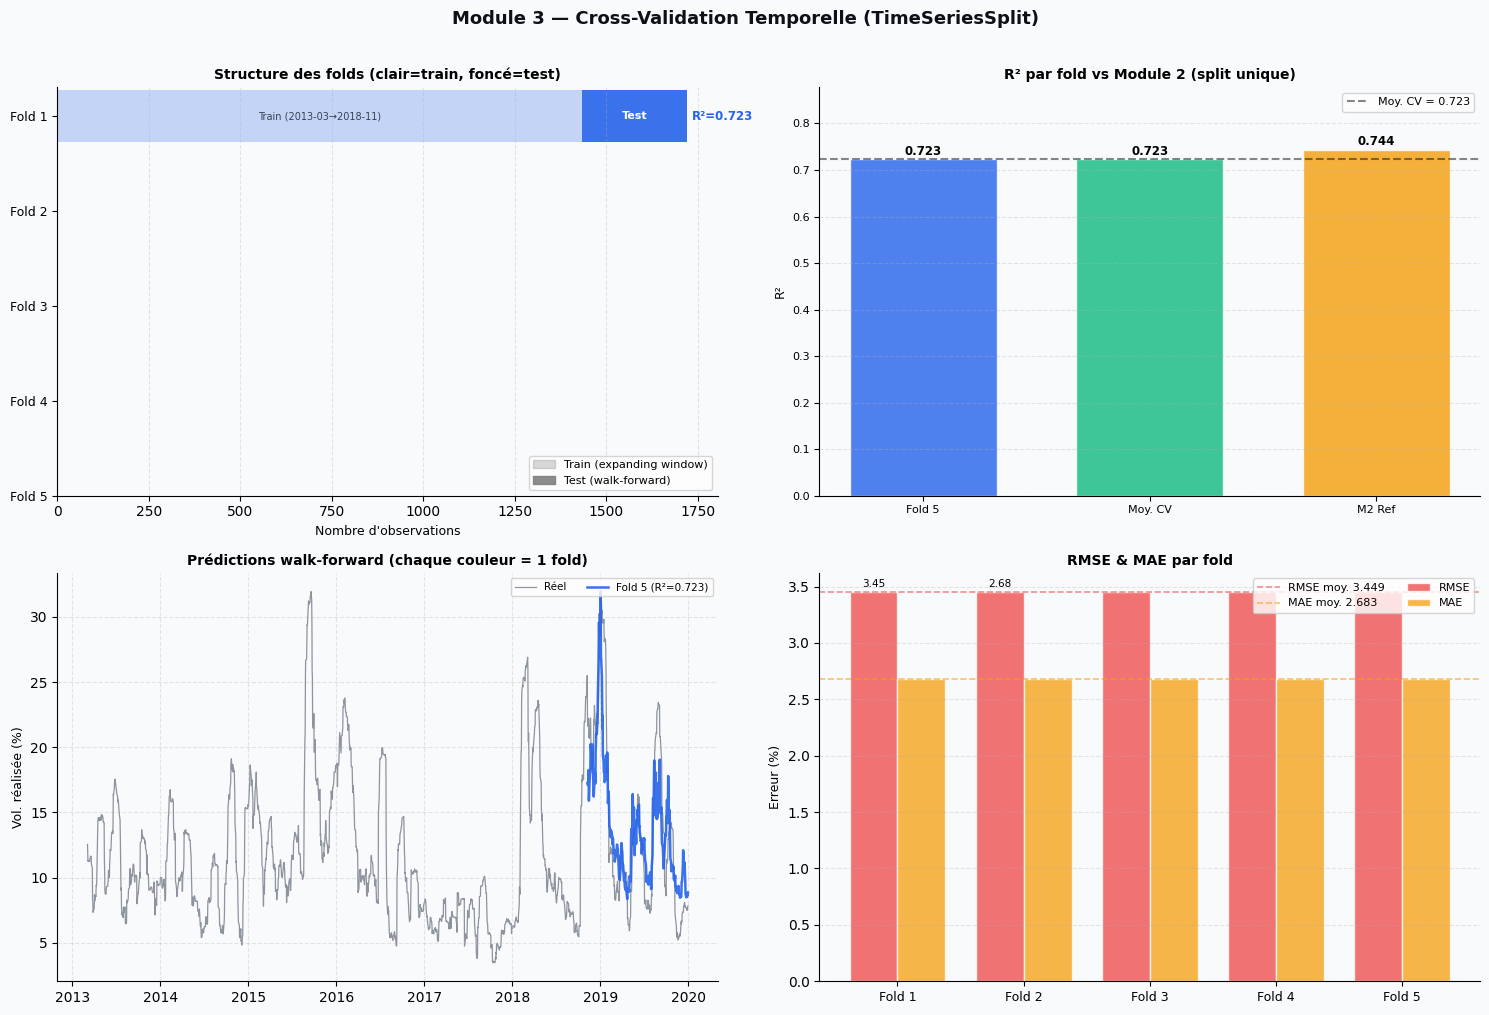


Graphique sauvegardé : module3_results.png


In [78]:
# =============================================================================
# 5. VISUALISATIONS
# =============================================================================

PLT_BG = '#F8FAFC'
fig, axes = plt.subplots(2, 2, figsize=(15, 10), facecolor=PLT_BG)
fig.suptitle('Module 3 — Cross-Validation Temporelle (TimeSeriesSplit)',
             fontsize=13, fontweight='bold', color='#0D1117', y=1.01)

# ── Fig 1 : Structure des folds ───────────────

ax = axes[0, 0]
for i, r in enumerate(fold_results):
    y_pos = N_SPLITS - i
    # Train bar (transparent)
    ax.barh(y_pos, r['train_size'], left=0, height=0.55,
            color=FOLD_COLORS[i], alpha=0.25)
    # Test bar (opaque)
    ax.barh(y_pos, r['test_size'], left=r['train_size'], height=0.55,
            color=FOLD_COLORS[i], alpha=0.90)
    ax.text(r['train_size'] + r['test_size'] + 15, y_pos,
            f"R²={r['R2']:.3f}", va='center', fontsize=8.5,
            color=FOLD_COLORS[i], fontweight='bold')
    ax.text(r['train_size'] / 2, y_pos,
            f"Train ({r['train_start']}→{r['train_end']})",
            va='center', ha='center', fontsize=7, color='#374151')
    ax.text(r['train_size'] + r['test_size'] / 2, y_pos,
            "Test", va='center', ha='center', fontsize=8,
            color='white', fontweight='bold')
ax.set_yticks(range(1, N_SPLITS + 1))
ax.set_yticklabels([f'Fold {N_SPLITS - i}' for i in range(N_SPLITS)], fontsize=9)
ax.set_xlabel("Nombre d'observations", fontsize=9)
ax.set_title('Structure des folds (clair=train, foncé=test)', fontsize=10, fontweight='bold')
ax.set_facecolor(PLT_BG)
ax.grid(True, alpha=0.3, linestyle='--', axis='x')
ax.spines[['top', 'right']].set_visible(False)
train_patch = mpatches.Patch(color='gray', alpha=0.3, label='Train (expanding window)')
test_patch = mpatches.Patch(color='gray', alpha=0.9, label='Test (walk-forward)')
ax.legend(handles=[train_patch, test_patch], fontsize=8, loc='lower right')

# ── Fig 2 : R² par fold + comparaison M2 ──────

ax = axes[0, 1]
methods = [f'Fold {r["fold"]}' for r in fold_results] + ['Moy. CV', 'M2 Ref']
r2_vals = r2_scores + [np.mean(r2_scores), r2_m2_test]
bar_cols = FOLD_COLORS + ['#0D1117', '#6B7280']
bars = ax.bar(methods, r2_vals, color=bar_cols, alpha=0.80, edgecolor='white', width=0.65)
ax.axhline(np.mean(r2_scores), color='#0D1117', lw=1.5, linestyle='--',
           alpha=0.5, label=f'Moy. CV = {np.mean(r2_scores):.3f}')
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title('R² par fold vs Module 2 (split unique)', fontsize=10, fontweight='bold')
ax.set_ylabel('R²', fontsize=9)
ax.set_ylim(0, max(r2_vals) * 1.18)
ax.legend(fontsize=8)
ax.set_facecolor(PLT_BG)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=8)

# ── Fig 3 : Prédictions walk-forward ──────────

ax = axes[1, 0]
ax.plot(df.index, y, color='#374151', lw=0.9, alpha=0.55, label='Réel', zorder=1)
for i, r in enumerate(fold_results):
    ax.plot(r['test_dates'], r['y_pred'],
            color=FOLD_COLORS[i], lw=1.8, alpha=0.9,
            label=f"Fold {r['fold']} (R²={r['R2']:.3f})", zorder=2)
ax.set_title('Prédictions walk-forward (chaque couleur = 1 fold)', fontsize=10, fontweight='bold')
ax.set_ylabel('Vol. réalisée (%)', fontsize=9)
ax.legend(fontsize=7.5, ncol=2, loc='upper right')
ax.set_facecolor(PLT_BG)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Fig 4 : RMSE et MAE par fold ──────────────

ax = axes[1, 1]
x_pos = np.arange(N_SPLITS)
width = 0.38
bars1 = ax.bar(x_pos - width/2, rmse_scores, width, color='#EF4444', alpha=0.75,
              edgecolor='white', label='RMSE')
bars2 = ax.bar(x_pos + width/2, mae_scores, width, color='#F59E0B', alpha=0.75,
              edgecolor='white', label='MAE')
ax.axhline(np.mean(rmse_scores), color='#EF4444', lw=1.2, linestyle='--',
           alpha=0.6, label=f'RMSE moy. {np.mean(rmse_scores):.3f}')
ax.axhline(np.mean(mae_scores), color='#F59E0B', lw=1.2, linestyle='--',
           alpha=0.6, label=f'MAE moy. {np.mean(mae_scores):.3f}')
for bar, val in zip(list(bars1)+list(bars2), rmse_scores+mae_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_SPLITS)], fontsize=9)
ax.set_title('RMSE & MAE par fold', fontsize=10, fontweight='bold')
ax.set_ylabel('Erreur (%)', fontsize=9)
ax.legend(fontsize=8, ncol=2)
ax.set_facecolor(PLT_BG)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('module3_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGraphique sauvegardé : module3_results.png")


In [79]:
# =============================================================================
# 6. BONUS — Évolution des coefficients à travers les folds
# =============================================================================
print("\n=== Stabilité des coefficients par fold ===")
print(f"{'Feature':12s}", end="")
for r in fold_results:
    print(f" Fold {r['fold']}", end="")
print()
for j, feat in enumerate(features):
    print(f"{feat:12s}", end="")
    for r in fold_results:
        print(f" {r['coef'][j]:+.3f} ", end="")
    print()


=== Stabilité des coefficients par fold ===
Feature      Fold 5
VIX_lag1     +0.528 
VIX_lag5     +0.637 
VIX_lag21    +0.150 
DVIX_lag1    -0.194 
